<a href="https://colab.research.google.com/github/MuhammadUsman-Khan/Time-Series-Water-Quality-Forecasting/blob/main/Time_Series_Water_Quality_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement:

The objective of this project is to forecast future Dissolved Oxygen (O2)  using historical multivariate water quality measurements.

The task is to predict the current O2 value at time 𝑡 using past measurements from previous time steps.

# Dataset Description

- The dataset contains data on the water quality for the Southern Bug (or
Pivdennyi Booh) River.

- There are 22 stations of the state water monitoring system.


- Data are monthly or quarterly. The number of observations on stations is different (from some to more than 20 years).


- File contains state monitoring data for 8 indicators for 2000-2021 for the Southern Bug (or Pivdennyi Booh) river.

# Importing the Dependencies

In [ ]:
!pip install statsmodels --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats
from scipy.stats import probplot

#1. Data Preparation
Preparing the Data for the further use of Analysis & Prediction

## Read Data Files

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vbmokin/wq-southern-bug-river-01052021")

print("Path to dataset files:", path)

100%|██████████| 56.7k/56.7k [00:00<00:00, 43.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/vbmokin/wq-southern-bug-river-01052021/versions/2


In [ ]:
water_df = pd.read_csv(path + "/PB_All_2000_2021.csv", delimiter=';')

## Basic inspection

In [ ]:
water_df.head()

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
0,1,17.02.2000,0.330,2.77,12.0,12.30,9.50,0.057,154.0,0.454,289.5
1,1,11.05.2000,0.044,3.00,51.6,14.61,17.75,0.034,352.0,0.090,1792.0
2,1,11.09.2000,0.032,2.10,24.5,9.87,13.80,0.173,416.0,0.200,2509.0
3,1,13.12.2000,0.170,2.23,35.6,12.40,17.13,0.099,275.2,0.377,1264.0
4,1,02.03.2001,0.000,3.03,48.8,14.69,10.00,0.065,281.6,0.134,1462.0


In [ ]:
# Checking the null values
water_df.isnull().sum()

,0
id,0
date,0
NH4,3
BSK5,1
Suspended,16
O2,3
NO3,1
NO2,3
SO4,49
PO4,28


There are null values so we can impute them

In [ ]:
water_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2861 entries, 0 to 2860
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         2861 non-null   int64  
 1   date       2861 non-null   object 
 2   NH4        2858 non-null   float64
 3   BSK5       2860 non-null   float64
 4   Suspended  2845 non-null   float64
 5   O2         2858 non-null   float64
 6   NO3        2860 non-null   float64
 7   NO2        2858 non-null   float64
 8   SO4        2812 non-null   float64
 9   PO4        2833 non-null   float64
 10  CL         2812 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 246.0+ KB


In [ ]:
water_df.shape

(2861, 11)

## Converting datatype

In [ ]:
water_df["date"] = pd.to_datetime(water_df["date"], format="%d.%m.%Y")
water_df = water_df.sort_values("date").reset_index(drop=True)

## Inspecting the date timespan

In [ ]:
# Checking the timespan of date column
water_df['date'].min().date(), "to", water_df['date'].max().date()

(datetime.date(2000, 1, 10), 'to', datetime.date(2021, 4, 7))

## Inspecting Number of Stations

In [ ]:
# Checking the number of stations in our dataset
water_df['id'].nunique()

22

In [ ]:
# now checking dataframe
water_df.head()

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
0,12,2000-01-10,1.5,1.5,9.0,15.2,7.4,0.32,37.6,0.06,36.7
1,16,2000-01-10,1.2,2.6,8.0,16.5,6.7,0.30,34.3,0.02,29.5
2,14,2000-01-10,1.3,1.9,9.0,15.8,6.3,0.30,40.1,1.61,31.3
3,15,2000-01-10,1.1,2.1,22.0,16.1,7.0,0.28,31.9,0.01,28.6
4,10,2000-01-11,2.5,2.6,7.0,8.7,7.7,0.15,40.9,0.04,34.0


# Exploratory Data Analysis

## Descriptive statistics

In [ ]:
water_df.describe()

,id,date,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
count,2861.000000,2861,2858.000000,2860.000000,2845.000000,2858.000000,2860.000000,2858.000000,2812.000000,2833.000000,2812.000000
mean,12.397064,2010-05-02 22:53:33.701502976,0.758734,4.316182,12.931905,9.508902,4.316846,0.246128,59.362313,0.418626,93.731991
min,1.000000,2000-01-10 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020000
25%,8.000000,2005-03-10 00:00:00,0.080000,2.160000,6.000000,7.092500,1.390000,0.030000,27.052500,0.130000,26.800000
50%,14.000000,2010-06-04 00:00:00,0.220000,3.800000,10.000000,8.995000,2.800000,0.059000,37.800000,0.270000,33.900000
75%,16.000000,2015-08-11 00:00:00,0.500000,5.800000,15.000000,11.520000,5.582500,0.125750,64.640000,0.470000,45.607500
max,22.000000,2021-04-07 00:00:00,39.427000,50.900000,595.000000,90.000000,133.400000,109.000000,3573.400000,13.879000,5615.280000
std,6.084226,NaN,2.486247,2.973997,16.543097,4.428260,6.881188,2.182777,96.582641,0.771326,394.512184


## Station Overview

In [ ]:
records = water_df.groupby('id').agg(
    count=('date','count'),
    start=('date','min'),
    end=('date','max')
).reset_index()

records['years'] = ((records['end'] - records['start']).dt.days / 365).round(1)

In [ ]:
print(records.to_string(index=False))

 id  count      start        end  years
  1     76 2000-02-17 2018-12-11   18.8
  2     77 2000-02-15 2018-10-08   18.7
  3    262 2000-01-12 2021-02-10   21.1
  4     91 2000-01-12 2018-10-08   18.8
  5     26 2019-01-28 2021-02-10    2.0
  6     71 2000-02-07 2018-10-17   18.7
  7     71 2000-02-02 2018-10-17   18.7
  8     70 2000-02-02 2018-10-17   18.7
  9     76 2000-02-02 2018-10-17   18.7
 10    252 2000-01-11 2021-04-07   21.3
 11     59 2000-06-21 2018-08-14   18.2
 12    148 2000-01-10 2018-10-17   18.8
 13    149 2006-07-11 2018-12-11   12.4
 14    259 2000-01-10 2021-04-06   21.3
 15    258 2000-01-10 2021-04-06   21.3
 16    253 2000-01-10 2021-04-06   21.3
 17     81 2000-03-23 2018-12-12   18.7
 18     80 2000-03-22 2018-12-12   18.7
 19     84 2000-01-27 2018-12-12   18.9
 20     82 2000-03-23 2018-12-12   18.7
 21     80 2000-03-23 2018-12-12   18.7
 22    256 2000-01-12 2021-02-10   21.1


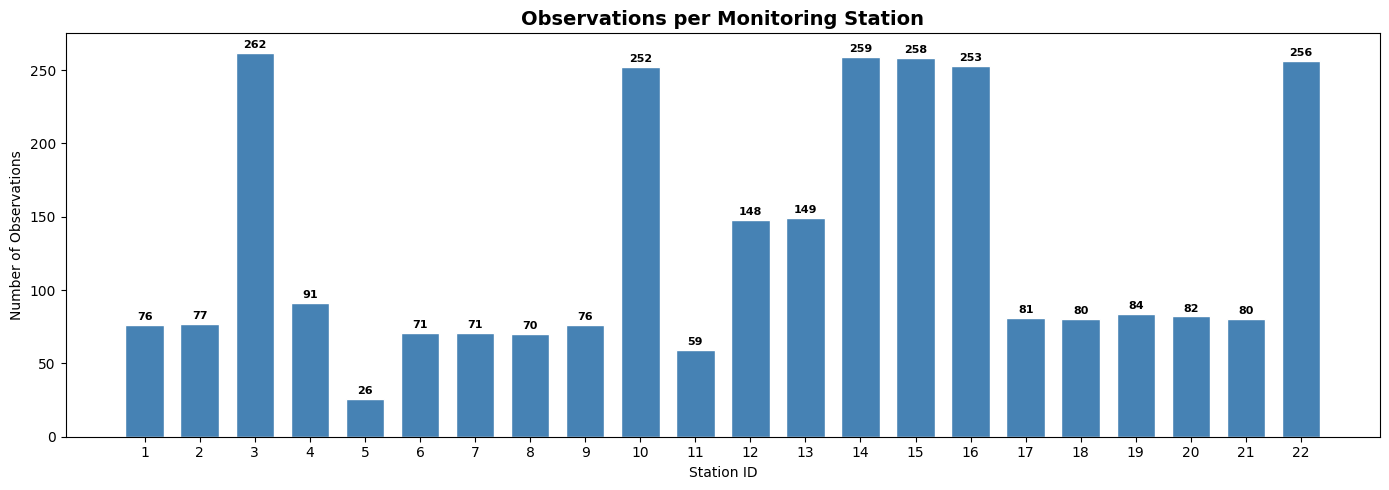

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(records['id'], records['count'], color='steelblue', edgecolor='white', width=0.7)
ax.set_xlabel('Station ID')
ax.set_ylabel('Number of Observations')
ax.set_title('Observations per Monitoring Station', fontsize=14, fontweight='bold')
ax.set_xticks(records['id'])
for bar, val in zip(bars, records['count']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, str(val),
            ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

Now we focus on station 3 only

In [ ]:
# updating the dataframe such that only station 3 values appears in it
water_df = water_df[water_df['id']==3].set_index('date').sort_index()

In [ ]:
# Dropping the ID column
water_df = water_df.drop(columns=['id'])

## Descriptive statistics

In [ ]:
water_df.describe()

,NH4,BSK5,Suspended,O2,NO3,NO2,SO4,PO4,CL
count,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000
mean,0.063847,2.013206,9.183168,11.133206,4.054882,0.035160,75.167492,0.337298,44.117977
std,0.081038,1.189934,11.086382,3.021865,2.693940,0.032475,21.165913,0.208304,7.587193
min,0.000000,0.100000,0.000000,5.430000,0.060000,0.000000,0.003000,0.000000,21.270000
25%,0.002250,1.222500,0.925000,8.610000,2.070000,0.018000,60.800000,0.177000,38.900000
50%,0.039500,1.770000,6.000000,10.895000,3.410000,0.027000,72.050000,0.332500,43.400000
75%,0.096750,2.405000,12.075000,13.360000,5.477500,0.040000,88.990000,0.471500,49.140000
max,0.700000,6.870000,67.000000,24.540000,14.720000,0.300000,147.840000,0.962000,68.120000


## Checking Date Timespans of station 3

In [ ]:
water_df.index.min().date(), "to" ,water_df.index.max().date()

(datetime.date(2000, 1, 12), 'to', datetime.date(2021, 2, 10))

## Checking Missing values

In [ ]:
water_df.isnull().sum()

,0
NH4,0
BSK5,0
Suspended,0
O2,0
NO3,0
NO2,0
SO4,0
PO4,0
CL,0


## Plotting all Parameters

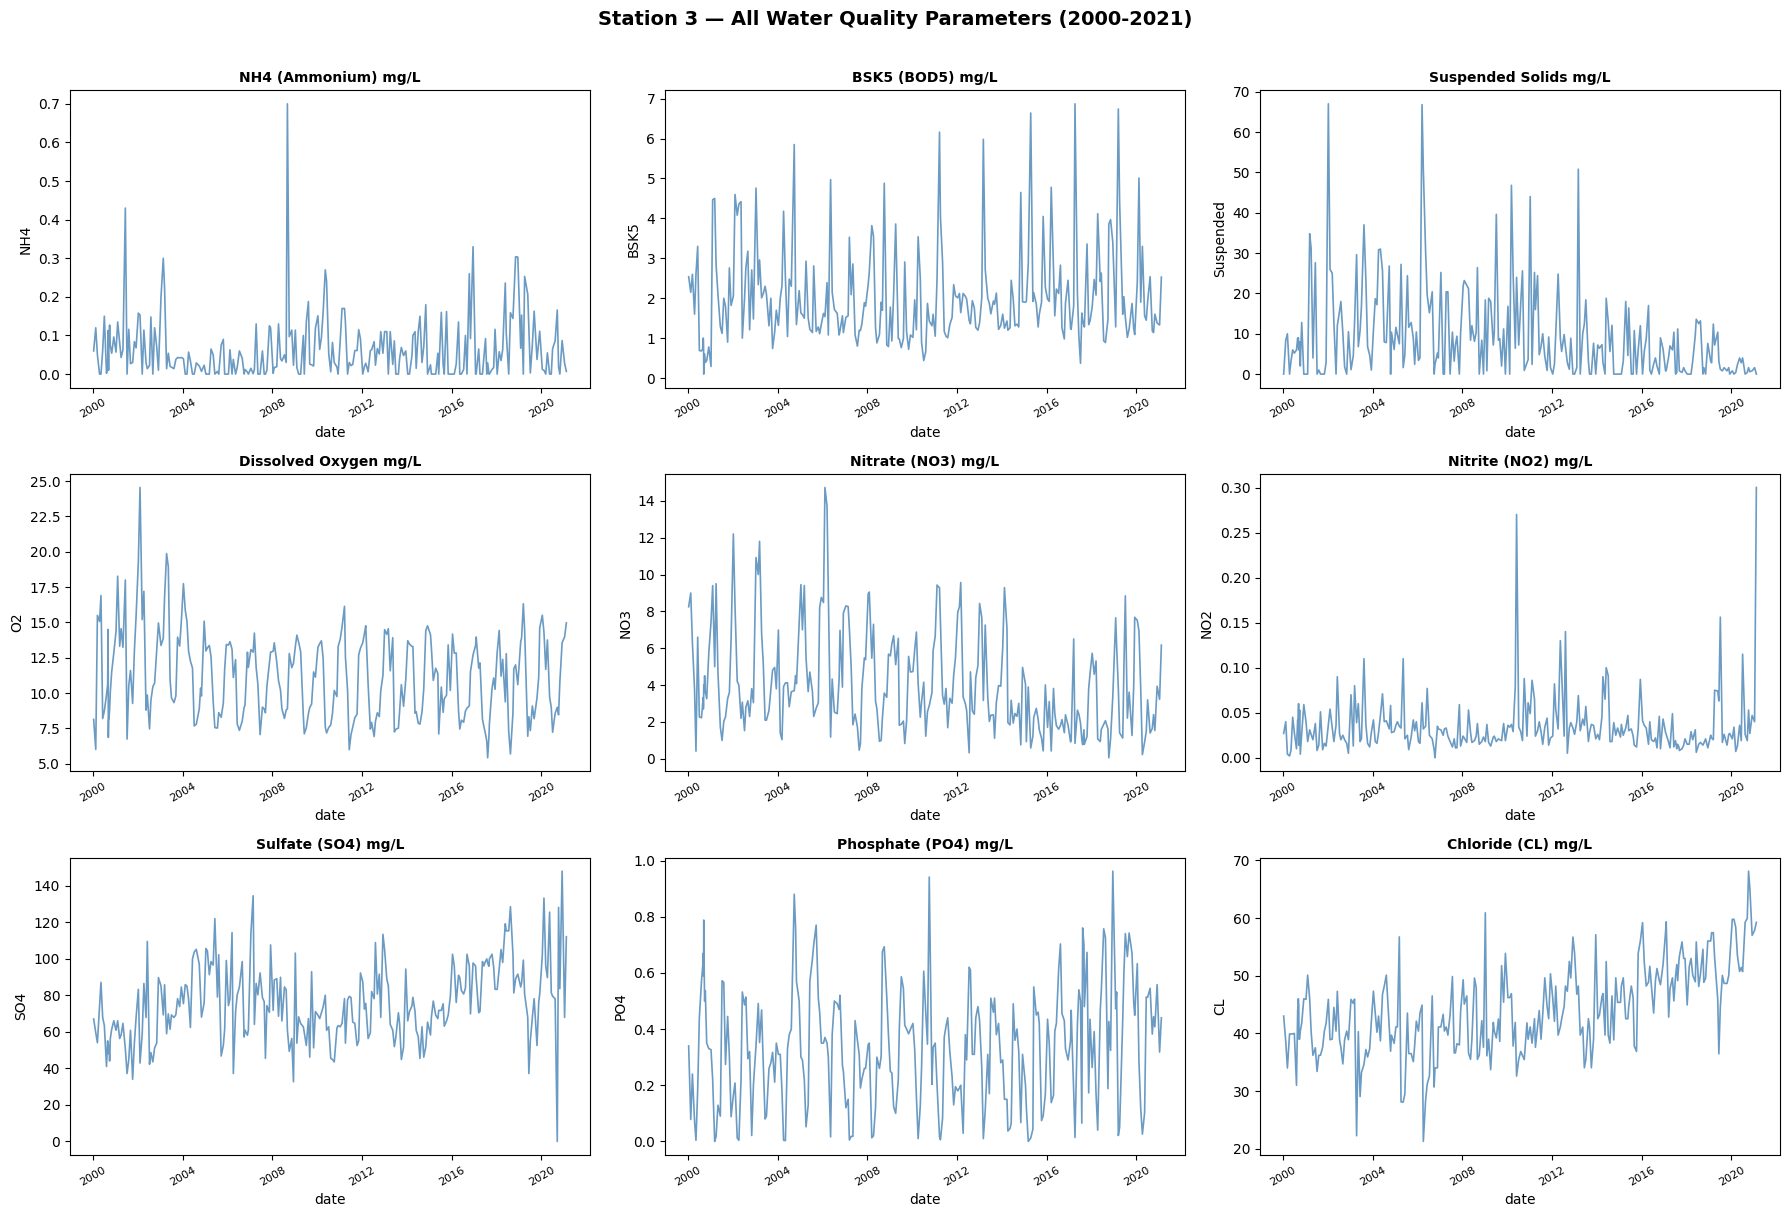

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

param_labels = {
    'NH4':       'NH4 (Ammonium) mg/L',
    'BSK5':      'BSK5 (BOD5) mg/L',
    'Suspended': 'Suspended Solids mg/L',
    'O2':        'Dissolved Oxygen mg/L',
    'NO3':       'Nitrate (NO3) mg/L',
    'NO2':       'Nitrite (NO2) mg/L',
    'SO4':       'Sulfate (SO4) mg/L',
    'PO4':       'Phosphate (PO4) mg/L',
    'CL':        'Chloride (CL) mg/L'
}

# Using water_df, which was filtered for station 3 and set to index 'date'
for ax, (param, label) in zip(axes, param_labels.items()):
    sns.lineplot(x=water_df.index, y=water_df[param], ax=ax, color='steelblue', linewidth=1.2, alpha=0.8)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, fontsize=8)

plt.suptitle('Station 3 — All Water Quality Parameters (2000-2021)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Observation:
- O2 shows clear seasonality.
- NO3 has an upward trend post-2005.
- NH4 and PO4 are low

## Correlation Heatmap

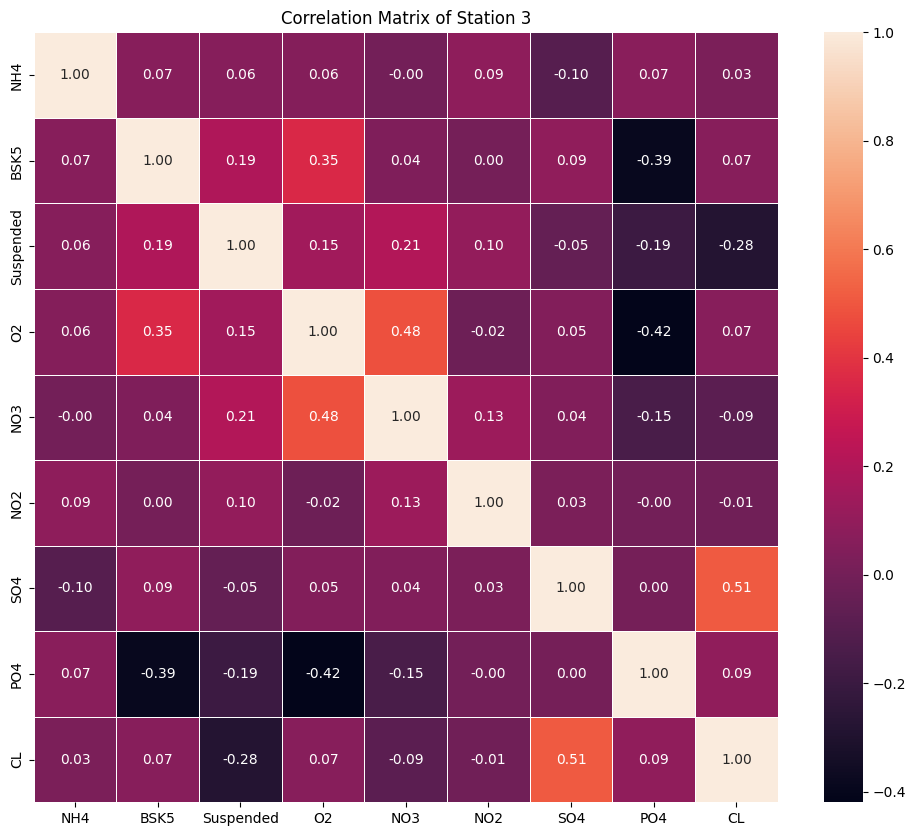

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(water_df.corr(), annot=True, fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Station 3')
plt.show()

# Transform Data

## Resampling to Regular Monthly Frequency

The data is approximately monthly but not exactly aligned. We resample to a regular monthly grid
using mean aggregation to get evenly spaced observations required for classical time series models.

In [ ]:
# Resample to monthly mean
PARAMS = ['NH4', 'BSK5', 'Suspended', 'O2', 'NO3', 'NO2', 'SO4', 'PO4', 'CL']
df_monthly = water_df[PARAMS].resample('MS').mean()

In [ ]:
# Forward-fill any remaining gaps (at most 1 month)
df_monthly = df_monthly.interpolate(method='time')

In [ ]:
print(f"Monthly resampled: {len(df_monthly)} months")
print(f"Date range: {df_monthly.index[0].date()} to {df_monthly.index[-1].date()}")
print(f"Any NaNs after interpolation: {df_monthly.isnull().sum().sum()}")
print("\nFirst 6 rows:")
print(df_monthly.head(6).round(3))

Monthly resampled: 254 months
Date range: 2000-01-01 to 2021-02-01
Any NaNs after interpolation: 0

First 6 rows:
              NH4  BSK5  Suspended     O2   NO3    NO2    SO4    PO4    CL
date                                                                      
2000-01-01  0.060  2.54        0.0   8.14  8.25  0.027  67.00  0.340  43.0
2000-02-01  0.120  2.15        8.4   6.02  9.00  0.040  59.50  0.078  38.6
2000-03-01  0.050  2.60       10.0  15.50  6.30  0.004  54.00  0.240  34.0
2000-04-01  0.000  1.60        0.0  15.07  3.75  0.002  73.60  0.071  39.9
2000-05-01  0.000  2.60        3.2  16.90  0.42  0.008  87.04  0.004  39.9
2000-06-01  0.061  3.30        6.0   8.20  6.60  0.045  67.80  0.184  39.9


## Dissolved Oxygen (O2)

In [ ]:
TARGET = 'O2'
series = df_monthly[TARGET].dropna()

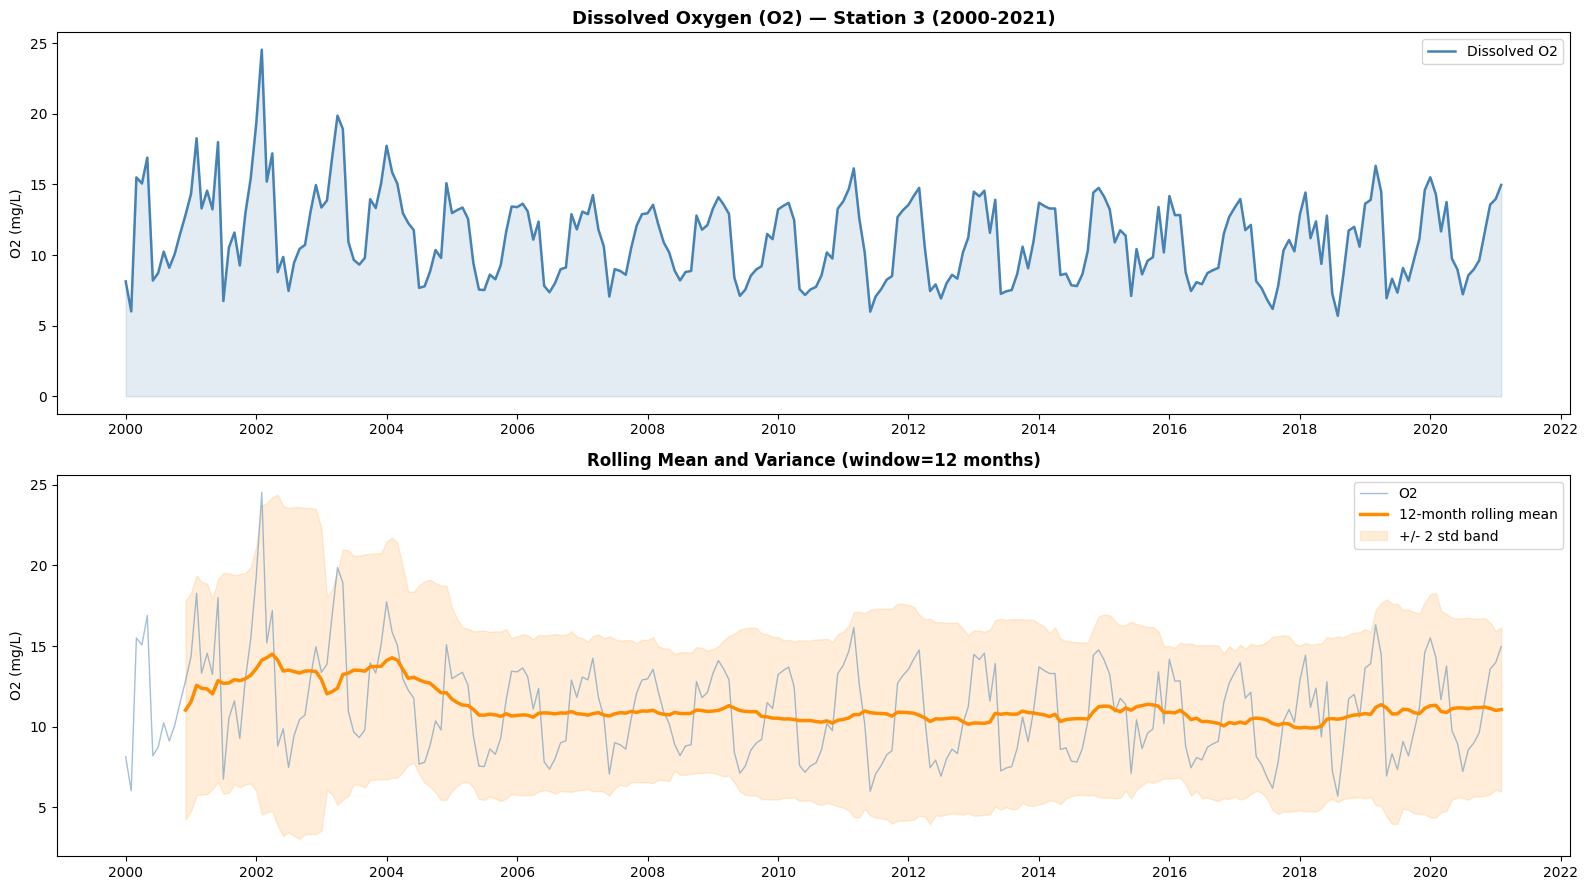

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Raw series
ax1 = axes[0]
ax1.plot(series, color='steelblue', linewidth=1.8, label='Dissolved O2')
ax1.fill_between(series.index, series, alpha=0.15, color='steelblue')
ax1.set_title('Dissolved Oxygen (O2) — Station 3 (2000-2021)', fontsize=13, fontweight='bold')
ax1.set_ylabel('O2 (mg/L)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.legend()

# Rolling stats
roll_mean = series.rolling(12).mean()
roll_std  = series.rolling(12).std()
ax2 = axes[1]
ax2.plot(series, color='steelblue', alpha=0.5, linewidth=1, label='O2')
ax2.plot(roll_mean, color='darkorange', linewidth=2.5, label='12-month rolling mean')
ax2.fill_between(series.index, roll_mean - 2*roll_std, roll_mean + 2*roll_std,
                 alpha=0.15, color='darkorange', label='+/- 2 std band')
ax2.set_title('Rolling Mean and Variance (window=12 months)', fontsize=12, fontweight='bold')
ax2.set_ylabel('O2 (mg/L)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
print(f"O2 Statistics:")
print(f"  Mean : {series.mean():.3f} mg/L")
print(f"  Std  : {series.std():.3f} mg/L")
print(f"  Min  : {series.min():.3f} mg/L")
print(f"  Max  : {series.max():.3f} mg/L")

O2 Statistics:
  Mean : 11.221 mg/L
  Std  : 2.998 mg/L
  Min  : 5.700 mg/L
  Max  : 24.540 mg/L


# Seasonal Boxplot

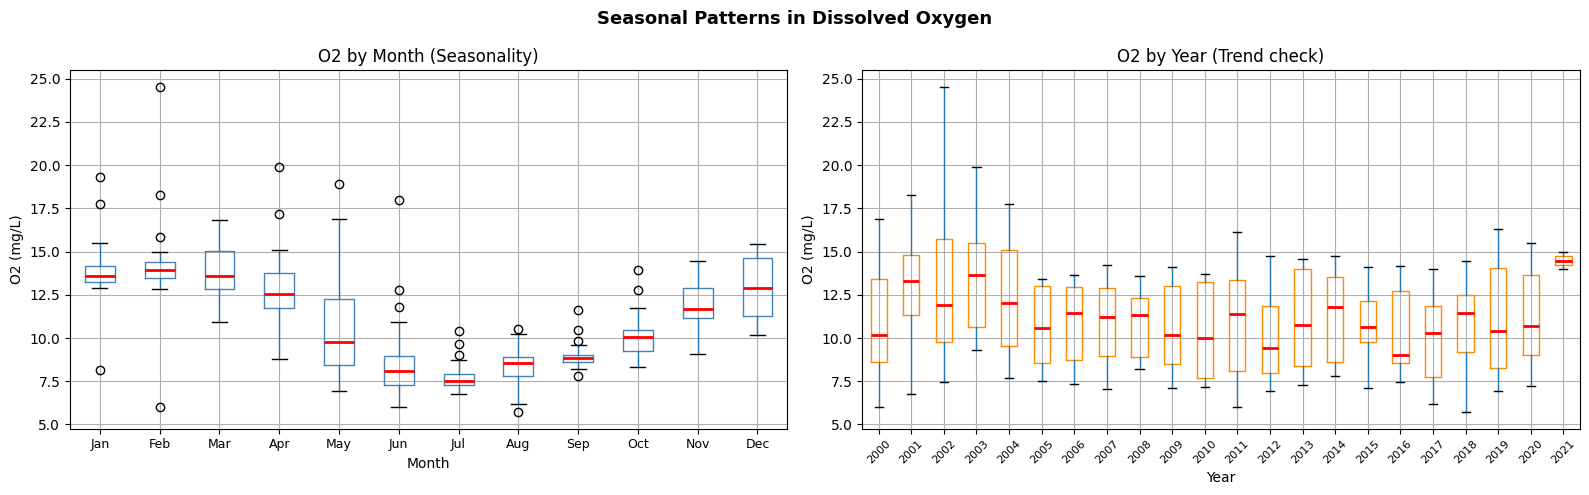

In [ ]:
# Seasonal box plots — by month and by year
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_box = pd.DataFrame({'O2': series, 'Month': series.index.month, 'Year': series.index.year})

# By month
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df_box.boxplot(column='O2', by='Month', ax=axes[0], grid=True,
               boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
axes[0].set_xticklabels(month_names, fontsize=9)
axes[0].set_title('O2 by Month (Seasonality)', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('O2 (mg/L)')
plt.sca(axes[0])
plt.title('O2 by Month (Seasonality)')

# By year
df_box.boxplot(column='O2', by='Year', ax=axes[1], grid=True,
               boxprops=dict(color='darkorange'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title('O2 by Year (Trend check)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('O2 (mg/L)')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, fontsize=8)
plt.sca(axes[1])
plt.title('O2 by Year (Trend check)')

plt.suptitle('')
fig.suptitle('Seasonal Patterns in Dissolved Oxygen', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Clear seasonal pattern: O2 peaks in winter/spring (cold water holds more oxygen)
and dips in summer (warm water + biological activity reduce oxygen).

# Time series Decompostion (O2)

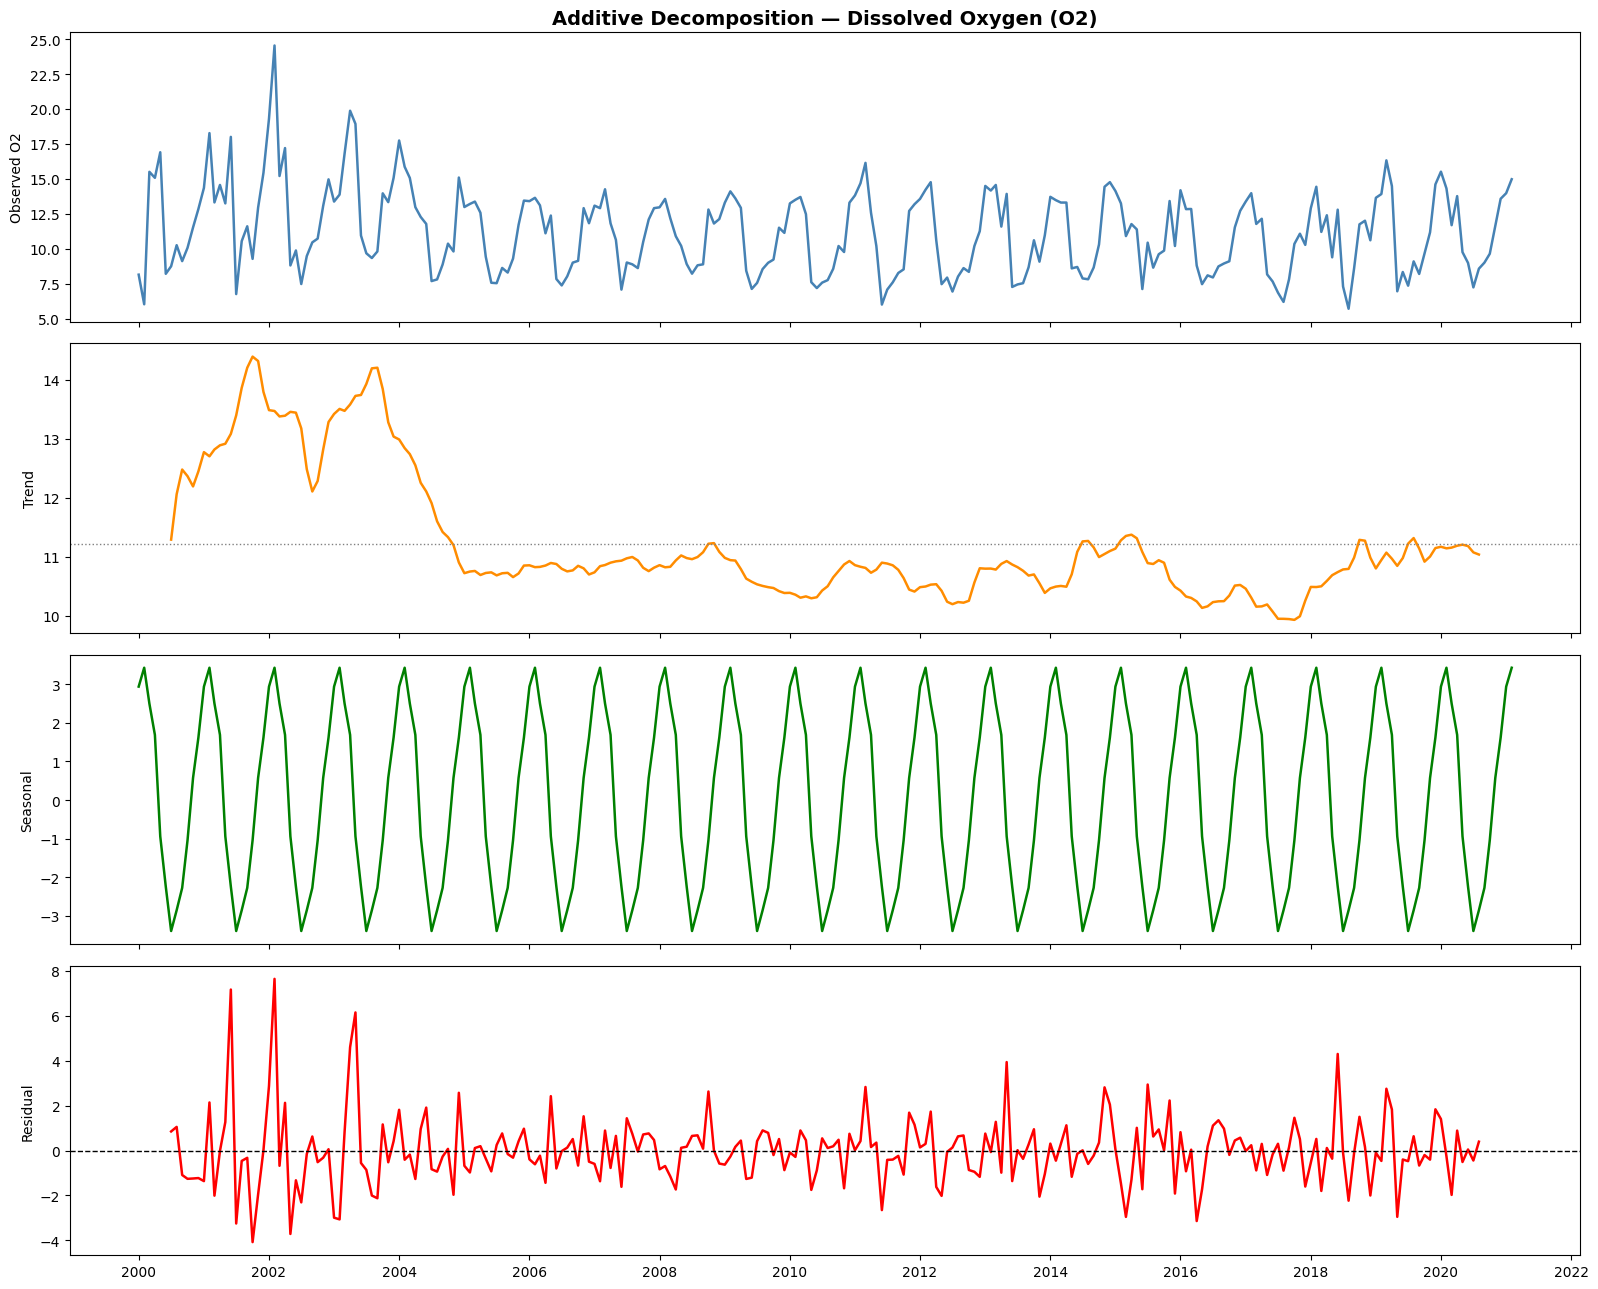

In [ ]:
decomp = seasonal_decompose(series, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(16, 13), sharex=True)
comps = [
    (series,          'Observed O2',  'steelblue'),
    (decomp.trend,    'Trend',        'darkorange'),
    (decomp.seasonal, 'Seasonal',     'green'),
    (decomp.resid,    'Residual',     'red'),
]
for ax, (data, title, color) in zip(axes, comps):
    ax.plot(data, color=color, linewidth=1.8)
    ax.set_ylabel(title, fontsize=10)
    if title == 'Residual':
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
    if title == 'Trend':
        ax.axhline(data.mean(), color='gray', linestyle=':', linewidth=1)

axes[0].set_title('Additive Decomposition — Dissolved Oxygen (O2)', fontsize=14, fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()

The trend shows a slight DECREASE in O2 over the 20 years,
consistent with gradual warming of water temperatures.

In [ ]:
trend_s    = max(0, 1 - decomp.resid.var() / (decomp.trend.dropna() + decomp.resid.dropna()).var())
seasonal_s = max(0, 1 - decomp.resid.var() / (decomp.seasonal + decomp.resid).var())
print(f"Trend Strength    : {trend_s:.3f}  ({'Strong' if trend_s>0.6 else 'Moderate' if trend_s>0.3 else 'Weak'})")
print(f"Seasonal Strength : {seasonal_s:.3f}  ({'Strong' if seasonal_s>0.6 else 'Moderate' if seasonal_s>0.3 else 'Weak'})")

Trend Strength    : 0.314  (Moderate)
Seasonal Strength : 0.697  (Strong)


# Stationary Testing

In [ ]:
def stationarity_report(s, name):
    print(f"  Stationarity Tests for: {name}")
    adf = adfuller(s.dropna(), autolag='AIC')
    print(f"\n  ADF Test:")
    print(f"    Statistic : {adf[0]:.4f}")
    print(f"    p-value   : {adf[1]:.4f}  (threshold: 0.05)")
    print(f"    Verdict   : {'STATIONARY' if adf[1]<0.05 else 'NON-STATIONARY'}")
    kp = kpss(s.dropna(), regression='c', nlags='auto')
    print(f"\n  KPSS Test:")
    print(f"    Statistic : {kp[0]:.4f}")
    print(f"    p-value   : {kp[1]:.4f}  (threshold: 0.05)")
    print(f"    Verdict   : {'NON-STATIONARY' if kp[1]<0.05 else 'STATIONARY'}")

stationarity_report(series, "O2 (original)")
print()
series_diff = series.diff().dropna()
stationarity_report(series_diff, "O2 (1st difference)")

  Stationarity Tests for: O2 (original)

  ADF Test:
    Statistic : -1.9913
    p-value   : 0.2904  (threshold: 0.05)
    Verdict   : NON-STATIONARY

  KPSS Test:
    Statistic : 0.6702
    p-value   : 0.0163  (threshold: 0.05)
    Verdict   : NON-STATIONARY

  Stationarity Tests for: O2 (1st difference)

  ADF Test:
    Statistic : -6.4052
    p-value   : 0.0000  (threshold: 0.05)
    Verdict   : STATIONARY

  KPSS Test:
    Statistic : 0.0165
    p-value   : 0.1000  (threshold: 0.05)
    Verdict   : STATIONARY


/tmp/ipykernel_398/250071657.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(s.dropna(), regression='c', nlags='auto')


# ACF & PACF Plots

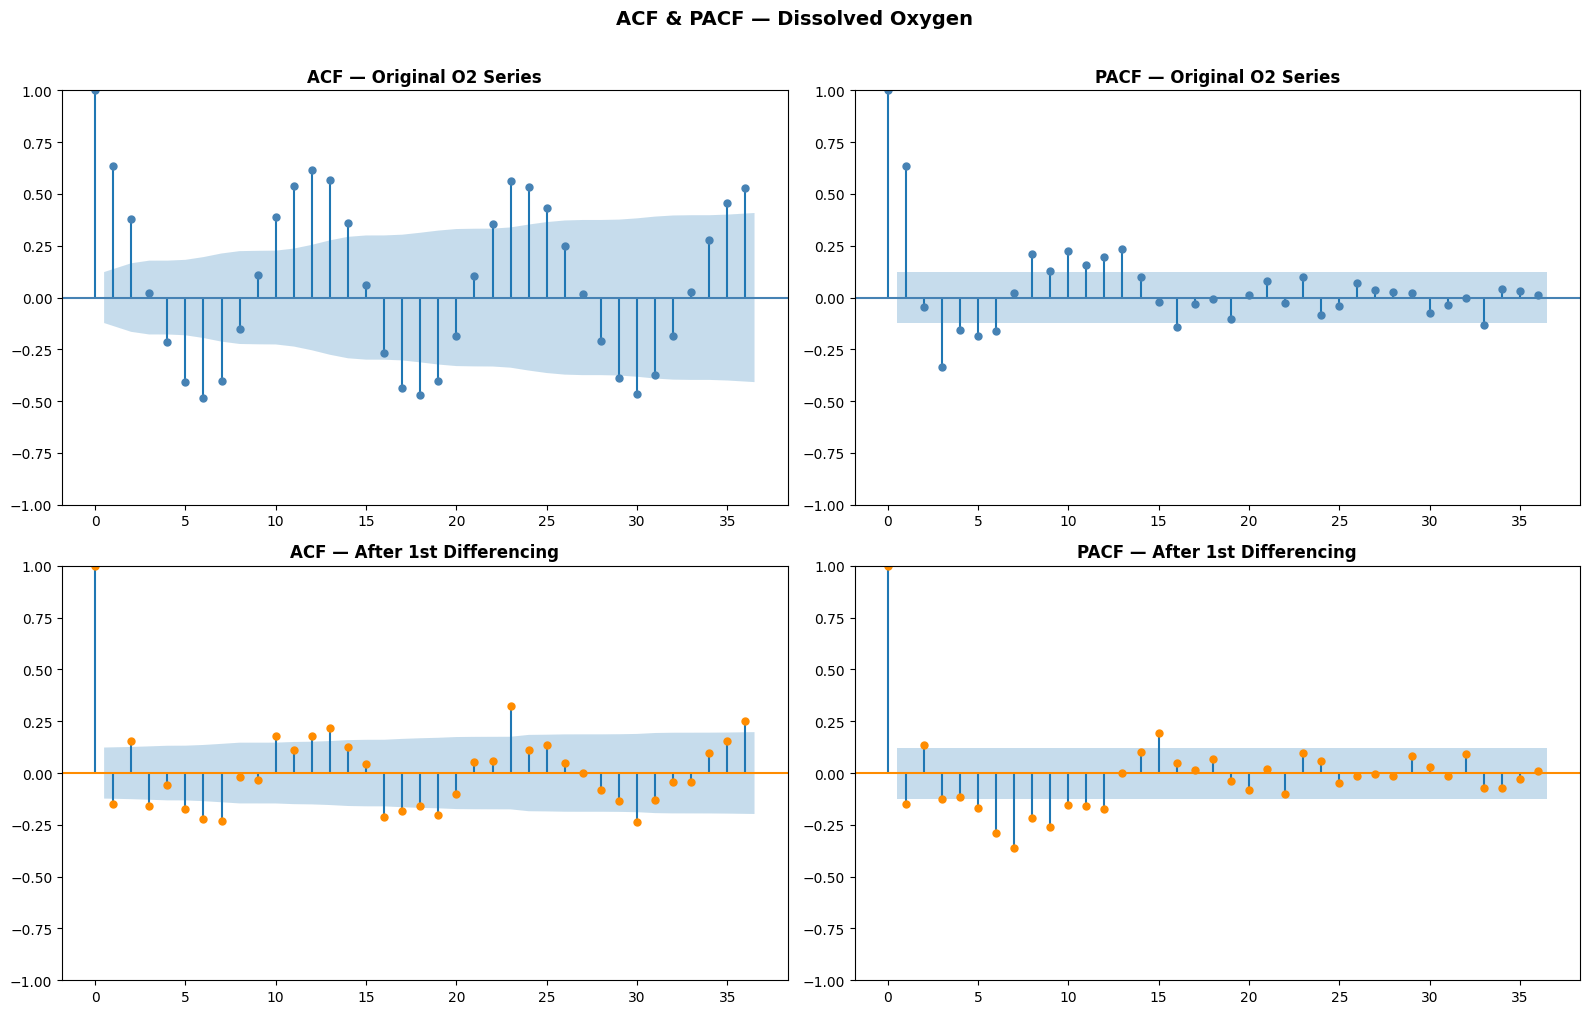

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_acf(series, lags=36, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('ACF — Original O2 Series', fontweight='bold')

plot_pacf(series, lags=36, ax=axes[0,1], color='steelblue', method='ywm')
axes[0,1].set_title('PACF — Original O2 Series', fontweight='bold')

plot_acf(series_diff, lags=36, ax=axes[1,0], color='darkorange')
axes[1,0].set_title('ACF — After 1st Differencing', fontweight='bold')

plot_pacf(series_diff, lags=36, ax=axes[1,1], color='darkorange', method='ywm')
axes[1,1].set_title('PACF — After 1st Differencing', fontweight='bold')

plt.suptitle('ACF & PACF — Dissolved Oxygen', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

ACF Interpretation:
  - Strong spikes at lags 6, 12, 18, 24 = clear ANNUAL SEASONALITY (s=12)
  - ACF decays slowly in original series = non-stationary
  - After differencing: ACF/PACF show manageable structure
  - Seasonal spike at lag 12 confirms we need SARIMA (P>=1, D>=1, s=12)

##  Splitting the Features & Target variable

In [ ]:
# Use last 24 months as test (2 full seasonal cycles)
TEST_MONTHS = 24
train = series[:-TEST_MONTHS]
test  = series[-TEST_MONTHS:]

print(f"Train: {train.index[0].date()} to {train.index[-1].date()} ({len(train)} months)")
print(f"Test : {test.index[0].date()} to {test.index[-1].date()} ({len(test)} months)")

Train: 2000-01-01 to 2019-02-01 (230 months)
Test : 2019-03-01 to 2021-02-01 (24 months)


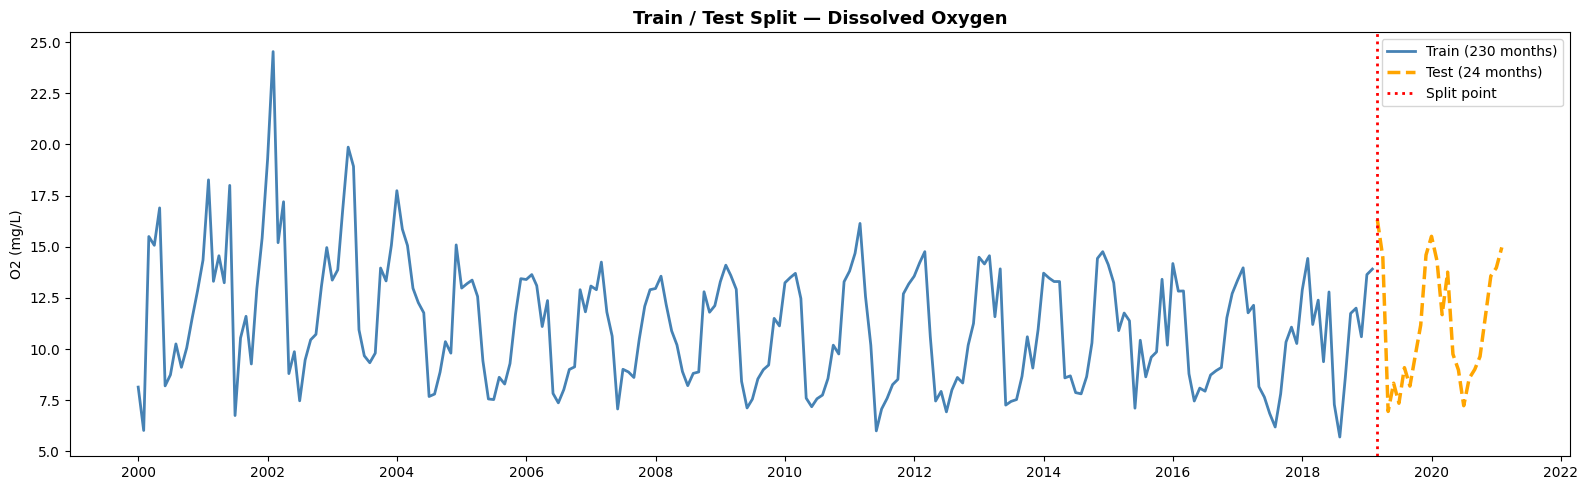

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train, color='steelblue', linewidth=2, label=f'Train ({len(train)} months)')
ax.plot(test, color='orange', linewidth=2.5, linestyle='--', label=f'Test ({len(test)} months)')
ax.axvline(test.index[0], color='red', linestyle=':', linewidth=2, label='Split point')
ax.set_title('Train / Test Split — Dissolved Oxygen', fontsize=13, fontweight='bold')
ax.set_ylabel('O2 (mg/L)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend()
plt.tight_layout()
plt.show()

results = {}

#  ML Model Fitting

## ARIMA

In [ ]:
arima_model = ARIMA(train, order=(1,1,1))
arima_fit   = arima_model.fit()
print(arima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               SARIMAX Results                                
Dep. Variable:                     O2   No. Observations:                  230
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -533.954
Date:                Thu, 12 Mar 2026   AIC                           1073.908
Time:                        20:54:51   BIC                           1084.209
Sample:                    01-01-2000   HQIC                          1078.064
                         - 02-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7614      0.148     -5.149      0.000      -1.051      -0.472
ma.L1          0.6090      0.187      3.254      0.001       0.242       0.976
sigma2         6.2034      0.466     13.325      0.0

In [ ]:
arima_fc   = arima_fit.forecast(steps=TEST_MONTHS)
arima_conf = arima_fit.get_forecast(steps=TEST_MONTHS).conf_int()

mae  = mean_absolute_error(test, arima_fc)
rmse = np.sqrt(mean_squared_error(test, arima_fc))
mape = np.mean(np.abs((test.values - arima_fc.values) / test.values)) * 100

results['ARIMA(1,1,1)'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'forecast': arima_fc}
print(f"ARIMA(1,1,1)  ->  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")

ARIMA(1,1,1)  ->  MAE=3.351  RMSE=4.096  MAPE=37.83%


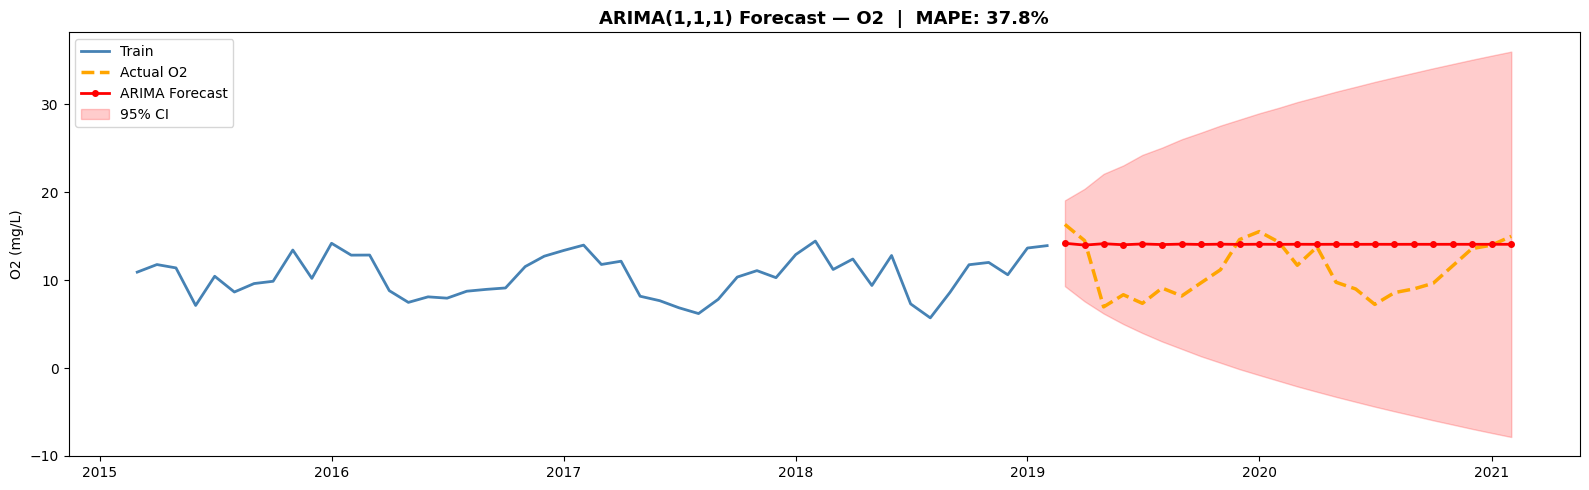

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train[-48:], color='steelblue', label='Train', linewidth=2)
ax.plot(test, color='orange', linewidth=2.5, linestyle='--', label='Actual O2')
ax.plot(arima_fc, color='red', linewidth=2, marker='o', markersize=4, label='ARIMA Forecast')
ax.fill_between(arima_conf.index, arima_conf.iloc[:,0], arima_conf.iloc[:,1],
                alpha=0.2, color='red', label='95% CI')
ax.set_title(f'ARIMA(1,1,1) Forecast — O2  |  MAPE: {mape:.1f}%', fontsize=13, fontweight='bold')
ax.set_ylabel('O2 (mg/L)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

## SARIMA

In [ ]:
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_fit   = sarima_model.fit(disp=False)

In [ ]:
sarima_fc   = sarima_fit.forecast(steps=TEST_MONTHS)
sarima_conf = sarima_fit.get_forecast(steps=TEST_MONTHS).conf_int()

mae  = mean_absolute_error(test, sarima_fc)
rmse = np.sqrt(mean_squared_error(test, sarima_fc))
mape = np.mean(np.abs((test.values - sarima_fc.values) / test.values)) * 100

results['SARIMA(1,1,1)(1,1,1,12)'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'forecast': sarima_fc}
print(f"SARIMA  ->  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")

SARIMA  ->  MAE=1.103  RMSE=1.491  MAPE=9.39%


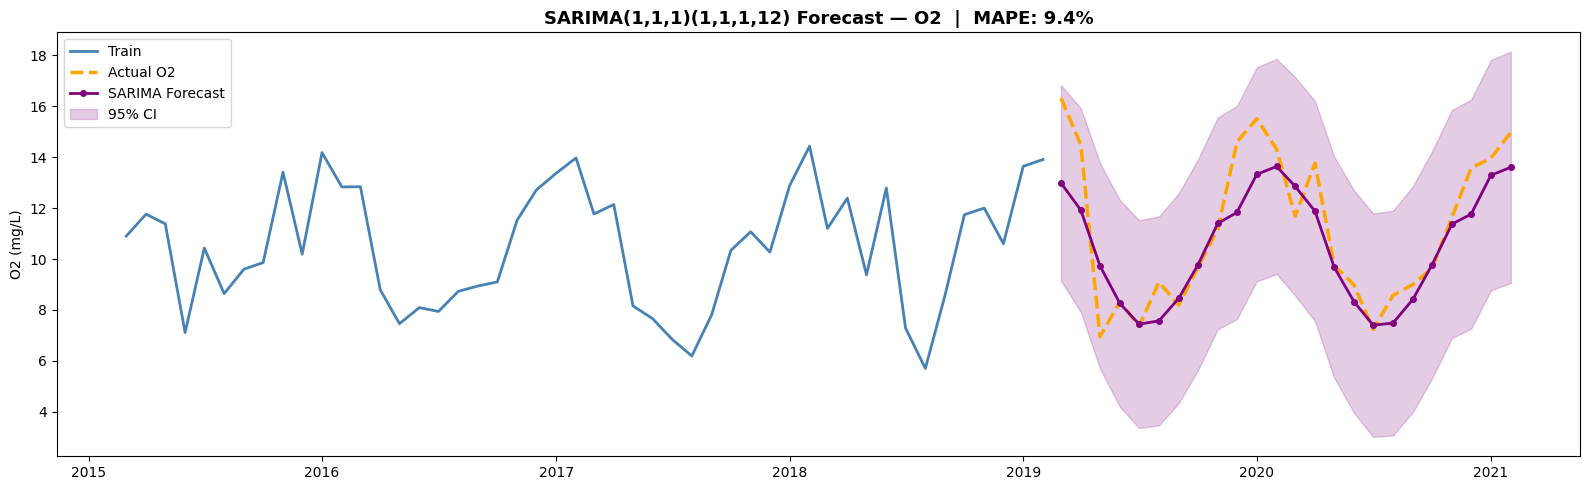

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train[-48:], color='steelblue', label='Train', linewidth=2)
ax.plot(test, color='orange', linewidth=2.5, linestyle='--', label='Actual O2')
ax.plot(sarima_fc, color='purple', linewidth=2, marker='o', markersize=4, label='SARIMA Forecast')
ax.fill_between(sarima_conf.index, sarima_conf.iloc[:,0], sarima_conf.iloc[:,1],
                alpha=0.2, color='purple', label='95% CI')
ax.set_title(f'SARIMA(1,1,1)(1,1,1,12) Forecast — O2  |  MAPE: {mape:.1f}%', fontsize=13, fontweight='bold')
ax.set_ylabel('O2 (mg/L)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

SARIMA correctly reproduces the winter peaks and summer troughs.

##  Holt-Winters Exponential Smoothing

In [ ]:
hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
hw_fit   = hw_model.fit(optimized=True)
hw_fc    = hw_fit.forecast(TEST_MONTHS)

mae  = mean_absolute_error(test, hw_fc)
rmse = np.sqrt(mean_squared_error(test, hw_fc))
mape = np.mean(np.abs((test.values - hw_fc.values) / test.values)) * 100

results['Holt-Winters'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'forecast': hw_fc}
print(f"Holt-Winters auto-fitted parameters:")
print(f"  alpha (level)    = {hw_fit.params['smoothing_level']:.4f}")
print(f"  beta  (trend)    = {hw_fit.params['smoothing_trend']:.4f}")
print(f"  gamma (seasonal) = {hw_fit.params['smoothing_seasonal']:.4f}")
print(f"\nMAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")

Holt-Winters auto-fitted parameters:
  alpha (level)    = 0.1234
  beta  (trend)    = 0.0000
  gamma (seasonal) = 0.0000

MAE=1.037  RMSE=1.417  MAPE=9.01%


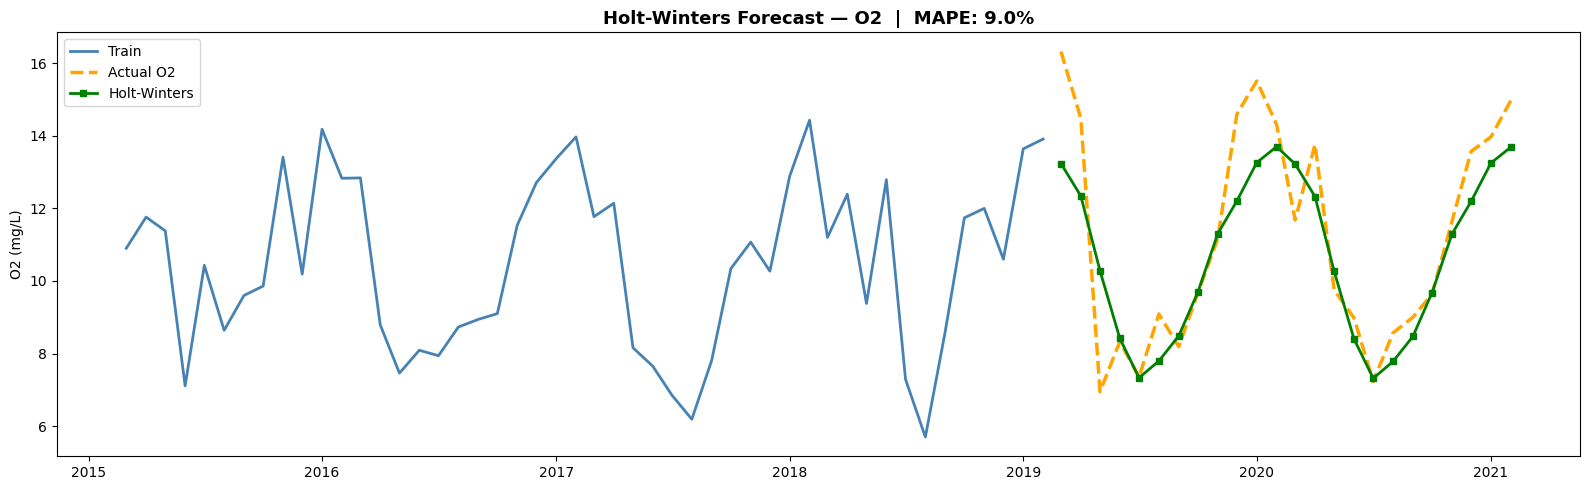

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train[-48:], color='steelblue', label='Train', linewidth=2)
ax.plot(test, color='orange', linewidth=2.5, linestyle='--', label='Actual O2')
ax.plot(hw_fc, color='green', linewidth=2, marker='s', markersize=4, label='Holt-Winters')
ax.set_title(f'Holt-Winters Forecast — O2  |  MAPE: {mape:.1f}%', fontsize=13, fontweight='bold')
ax.set_ylabel('O2 (mg/L)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

## ML Forecasting — Gradient Boosting with Lag Features

In [ ]:
def create_features(s, lags=[1,2,3,6,12,24]):
    dff = pd.DataFrame({'y': s})
    for lag in lags:
        dff[f'lag_{lag}'] = dff['y'].shift(lag)
    dff['month']     = dff.index.month
    dff['year']      = dff.index.year
    dff['trend_idx'] = np.arange(len(dff))
    dff['month_sin'] = np.sin(2*np.pi*dff['month']/12)
    dff['month_cos'] = np.cos(2*np.pi*dff['month']/12)
    return dff.dropna()

In [ ]:
feat_df = create_features(series)
X = feat_df.drop('y', axis=1)
y_all = feat_df['y']

split_dt = test.index[0]
X_tr = X[X.index < split_dt];   y_tr = y_all[y_all.index < split_dt]
X_te = X[X.index >= split_dt];  y_te = y_all[y_all.index >= split_dt]

print(f"X_train: {X_tr.shape},  X_test: {X_te.shape}")
print("Features:", X_tr.columns.tolist())

gb = GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
gb.fit(X_tr, y_tr)
gb_fc = pd.Series(gb.predict(X_te), index=X_te.index)

mae  = mean_absolute_error(y_te, gb_fc)
rmse = np.sqrt(mean_squared_error(y_te, gb_fc))
mape = np.mean(np.abs((y_te.values - gb_fc.values) / y_te.values)) * 100

results['GradientBoosting'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'forecast': gb_fc}
print(f"\nGradient Boosting  ->  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")

X_train: (206, 11),  X_test: (24, 11)
Features: ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'month', 'year', 'trend_idx', 'month_sin', 'month_cos']

Gradient Boosting  ->  MAE=1.098  RMSE=1.466  MAPE=9.65%


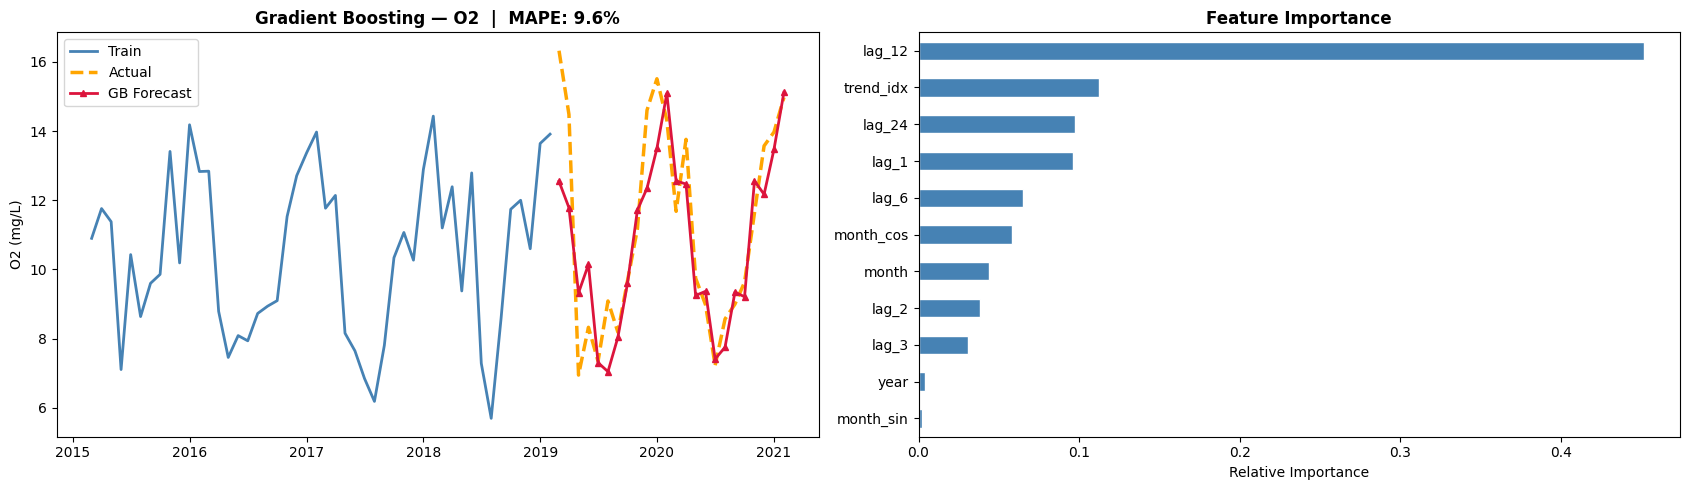

In [ ]:
fi = pd.Series(gb.feature_importances_, index=X_tr.columns).sort_values(ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
axes[0].plot(train[-48:], color='steelblue', label='Train', linewidth=2)
axes[0].plot(y_te, color='orange', linewidth=2.5, linestyle='--', label='Actual')
axes[0].plot(gb_fc, color='crimson', linewidth=2, marker='^', markersize=5, label='GB Forecast')
axes[0].set_title(f'Gradient Boosting — O2  |  MAPE: {mape:.1f}%', fontweight='bold')
axes[0].set_ylabel('O2 (mg/L)'); axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fi.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Feature Importance', fontweight='bold')
axes[1].set_xlabel('Relative Importance')
plt.tight_layout()
plt.show()

#  Model Comparison

In [ ]:
comp = pd.DataFrame({
    m: {'MAE': v['MAE'], 'RMSE': v['RMSE'], 'MAPE(%)': v['MAPE']}
    for m, v in results.items()
}).T.round(3)
comp['Rank'] = comp['MAPE(%)'].rank().astype(int)
comp_sorted  = comp.sort_values('MAPE(%)')
print("            MODEL COMPARISON TABLE — O2 Forecasting")
print(comp_sorted.to_string())
best = comp['MAPE(%)'].idxmin()
print(f"\nBest model: {best}  (MAPE = {comp.loc[best,'MAPE(%)']:.2f}%)")


            MODEL COMPARISON TABLE — O2 Forecasting
                           MAE   RMSE  MAPE(%)  Rank
Holt-Winters             1.037  1.417    9.007     1
SARIMA(1,1,1)(1,1,1,12)  1.103  1.491    9.389     2
GradientBoosting         1.098  1.466    9.646     3
ARIMA(1,1,1)             3.351  4.096   37.826     4

Best model: Holt-Winters  (MAPE = 9.01%)


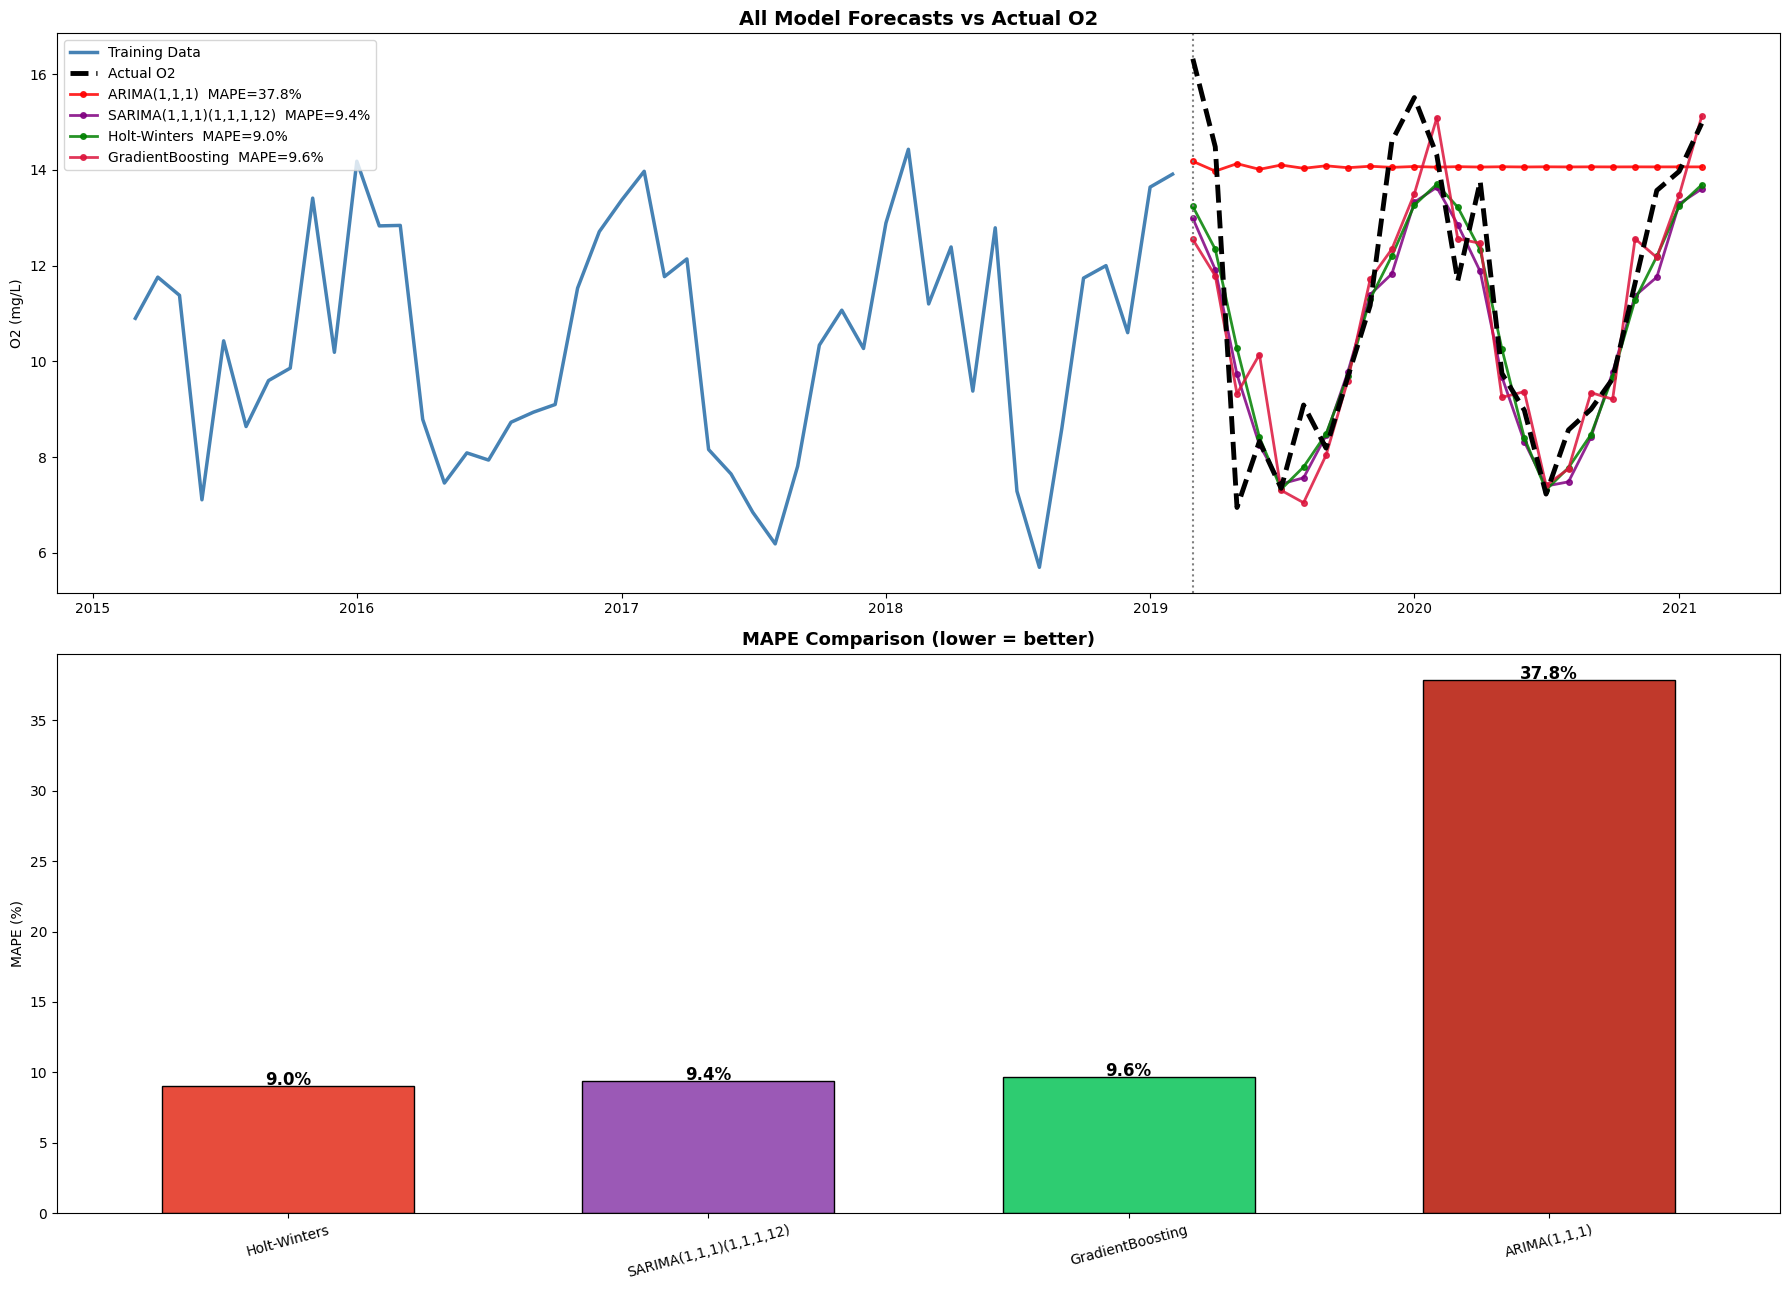

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(18, 13))

ax1 = axes[0]
ax1.plot(train[-48:], color='steelblue', linewidth=2.5, label='Training Data')
ax1.plot(test, color='black', linewidth=3.5, linestyle='--', label='Actual O2', zorder=10)
plot_cols = ['red','purple','green','crimson']
for (mn, res), c in zip(results.items(), plot_cols):
    ax1.plot(res['forecast'], color=c, linewidth=2, marker='o', markersize=4, alpha=0.85,
             label=f"{mn}  MAPE={res['MAPE']:.1f}%")
ax1.axvline(test.index[0], color='gray', linestyle=':', linewidth=1.5)
ax1.set_title('All Model Forecasts vs Actual O2', fontsize=14, fontweight='bold')
ax1.set_ylabel('O2 (mg/L)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.legend(loc='upper left', fontsize=10)

ax2 = axes[1]
bar_c = ['#e74c3c','#9b59b6','#2ecc71','#c0392b']
comp_sorted['MAPE(%)'].plot(kind='bar', ax=ax2, color=bar_c, edgecolor='black', width=0.6)
ax2.set_title('MAPE Comparison (lower = better)', fontsize=13, fontweight='bold')
ax2.set_ylabel('MAPE (%)'); ax2.tick_params(axis='x', rotation=15)
for i, val in enumerate(comp_sorted['MAPE(%)']):
    ax2.text(i, val+0.1, f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout(); plt.show()

## Future Forecast — 24 Months Ahead (2021-2023) using Best Model

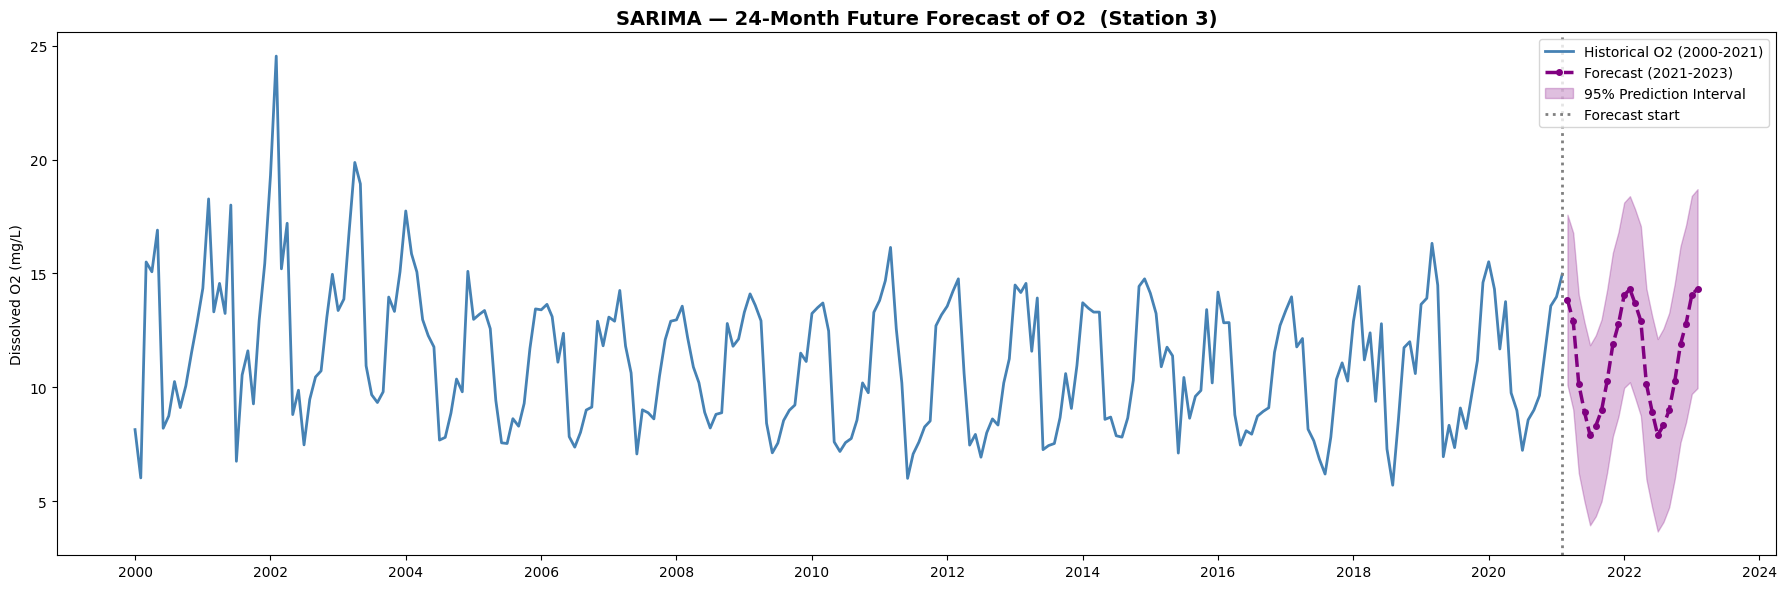

Forecast values:
            forecast  lower_95  upper_95
2021-03-01    13.840    10.104    17.576
2021-04-01    12.904     9.026    16.781
2021-05-01    10.144     6.232    14.056
2021-06-01     8.913     4.980    12.847
2021-07-01     7.893     3.939    11.847
2021-08-01     8.309     4.336    12.282
2021-09-01     8.984     4.992    12.976
2021-10-01    10.261     6.250    14.272
2021-11-01    11.878     7.848    15.908
2021-12-01    12.760     8.710    16.809
2022-01-01    14.041     9.974    18.109
2022-02-01    14.303    10.217    18.390
2022-03-01    13.680     9.543    17.817
2022-04-01    12.909     8.747    17.072
2022-05-01    10.144     5.960    14.329
2022-06-01     8.927     4.721    13.132
2022-07-01     7.892     3.666    12.118
2022-08-01     8.327     4.080    12.574
2022-09-01     8.997     4.730    13.265
2022-10-01    10.261     5.974    14.549
2022-11-01    11.886     7.578    16.193
2022-12-01    12.789     8.461    17.117
2023-01-01    14.053     9.705    18.401

In [ ]:
# Re-fit SARIMA on full data, forecast 24 months into future
best_model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,12))
best_fit   = best_model.fit(disp=False)

future_fc   = best_fit.forecast(steps=24)
future_conf = best_fit.get_forecast(steps=24).conf_int()

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(series, color='steelblue', linewidth=2, label='Historical O2 (2000-2021)')
ax.plot(future_fc, color='purple', linewidth=2.5, marker='o', markersize=4,
        linestyle='--', label='Forecast (2021-2023)')
ax.fill_between(future_conf.index, future_conf.iloc[:,0], future_conf.iloc[:,1],
                alpha=0.25, color='purple', label='95% Prediction Interval')
ax.axvline(series.index[-1], color='gray', linestyle=':', linewidth=2, label='Forecast start')
ax.set_title('SARIMA — 24-Month Future Forecast of O2  (Station 3)', fontsize=14, fontweight='bold')
ax.set_ylabel('Dissolved O2 (mg/L)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("Forecast values:")
fc_df = pd.DataFrame({'forecast': future_fc.round(3),
                      'lower_95': future_conf.iloc[:,0].round(3),
                      'upper_95': future_conf.iloc[:,1].round(3)})
print(fc_df.to_string())
